In [15]:
from src.QC import *
from src.plotting_functions import *
pio.renderers.default = "png"


hme1_1 = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260807_hTERT_HEM1_1_processed_phPlus.tsv", sep="\t", low_memory=False) #.fillna(0)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False)
hek_1 = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260807_HEK293T_processed_phPlus.tsv", sep="\t", low_memory=False)
# hme1_mutants = pd.read_csv("../../Experiment/hme1_mutants_test/Data/Processed/20260709_hTERT_HME1_mutants_processed_phPlus_filtered.tsv", sep="\t", low_memory=False)
# hme1_diapasef = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260814_peptide_MS2quant_None_transformed.tsv",sep="\t",)

In [2]:
TMT_plex_sample = hme1_2[['site',
                 'n:reps',
                 'WT_raw:abs_EGF_starve_r1',
                 'WT_raw:abs_EGF_starve_r2',
                 'WT_raw:abs_EGF_starve_r3',
                 'WT_raw:abs_EGF_starve_r4']]

CELL_LINES = ["WT"] #, "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]

# MSMS data quality check


## Value missingness and counts

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Missing values per sample - hek_1'}, xlabel='Sample', ylabel='% missing // zero values'>)

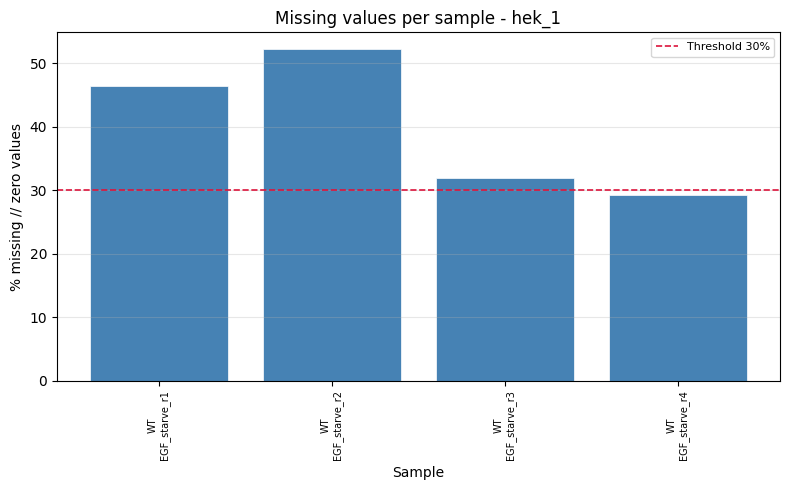

In [3]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]

missing_values_per_sample(
    TMT_plex_sample,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_threshold=0.30,
    figsize=None,
    title="Missing values per sample - hek_1",
    ax=None,
)

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Detected peptides per sample'}, xlabel='Sample', ylabel='Number of detected peptides'>)

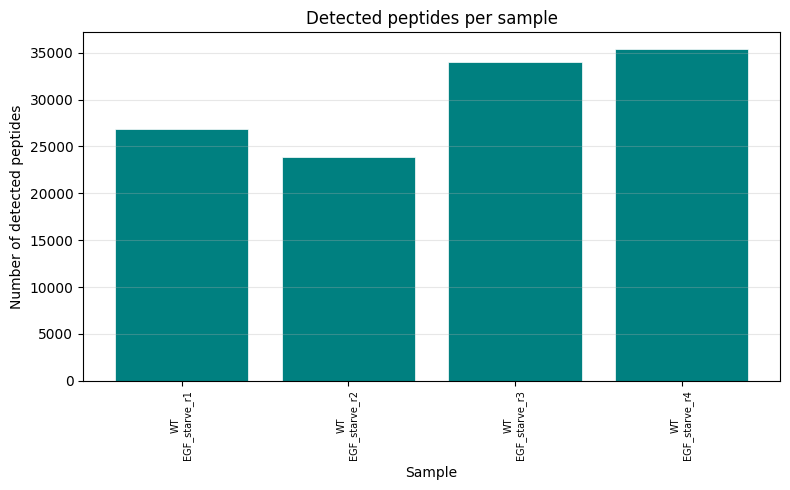

In [4]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
peptide_count_per_sample(
    TMT_plex_sample,
    cell_lines=["WT"], # "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_value=0.0,
    figsize=None,
    title="Detected peptides per sample",
    ax=None,
)

Replicate detection summary (50002 sites):
  1 replicate : 32.6%
  2 replicates: 21.5%
  3 replicates: 19.0%
  4 replicates: 26.9%


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Replicate count distribution - hek_1'}, xlabel='Number of replicates detected', ylabel='Number of peptides'>)

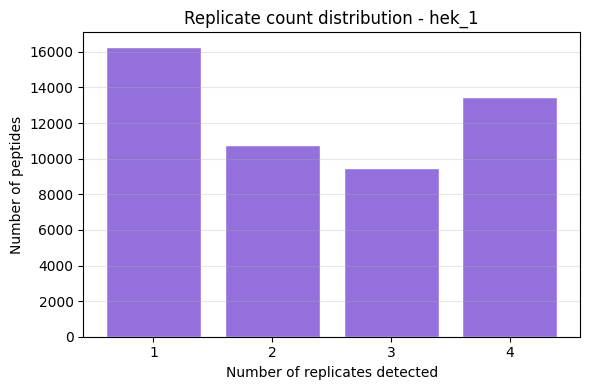

In [5]:
nreps_distribution(
    TMT_plex_sample,
    nreps_col="n:reps",
    figsize=(6, 4),
    title="Replicate count distribution - hek_1",
    ax=None,
)

(<Figure size 400x1000 with 1 Axes>,
 <Axes: title={'center': 'Replicate detection map'}, ylabel='50002 sites'>)

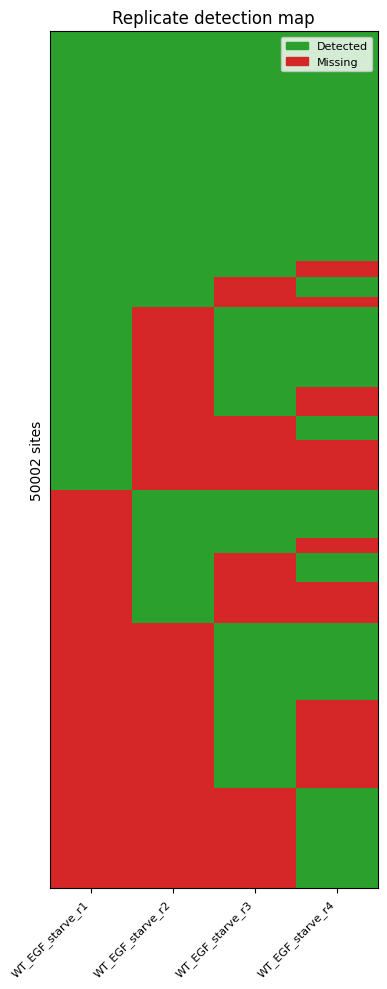

In [7]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
replicate_detection_map(
    TMT_plex_sample,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_value=0.0,
    figsize=None,
    title="Replicate detection map",
    ax=None,
)

### Localization completeness — hme1_2

A peptide is **fully localized** when `NumPhos == LocalizedNumPhos`: the search detected *n*
phosphorylations and could assign all *n* to specific S/T/Y residues. Where `LocalizedNumPhos`
is lower, the peptide is known to be phosphorylated but at least one modification floats
between candidate residues, so that row's site-level identity is partly ambiguous.

This is not only an identification-quality number. `src/kinase_prediction.py` scores
**single-localized sites only**, so partially localized peptides drop out of every kinase-based
analysis downstream without ever being filtered explicitly.

The second panel crosses the flag with `n:reps`, because the two weaknesses compound: a peptide
that is both ambiguously localized *and* seen in one replicate of four carries almost no usable
information. The `all peptides` bars are the same distribution over the whole dataset, so it is
visible whether localization completeness and replication are related or independent.

Localization completeness (50002 phospho-peptides):
  all phosphosites localized (NumPhos == LocalizedNumPhos) : 33439 (66.9%)
  not all phosphosites localized                           : 16563 (33.1%)
    no phosphosite localized (LocalizedNumPhos == 0)       : 15290 (30.6%)
    some phosphorylations could not be localized           : 1273 (2.5%)

Peptides with all phosphosites localized, by number of replicates detected:
        n_peptides  n_fully_localized  pct_fully_localized
n:reps                                                    
1            16283               9531                 58.5
2            10746               6677                 62.1
3             9505               6505                 68.4
4            13468              10726                 79.6


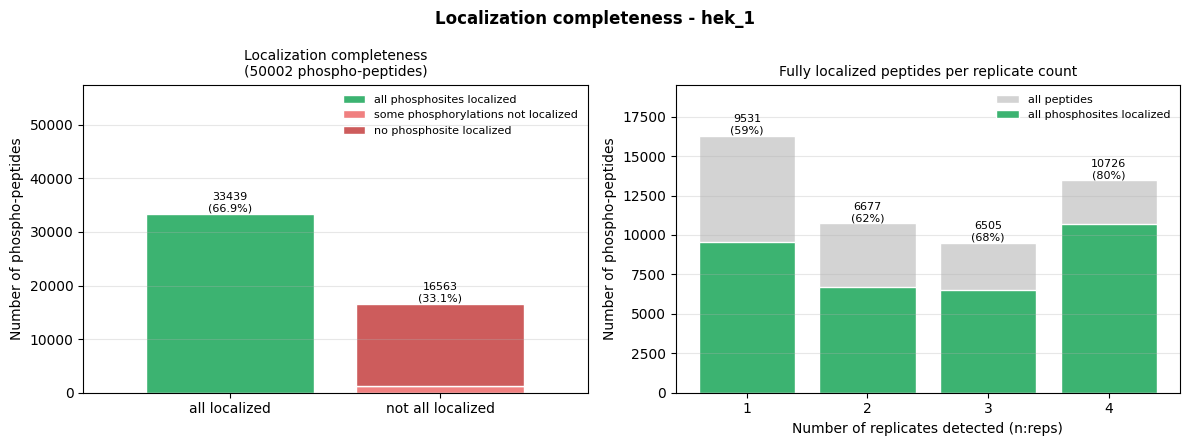

In [8]:
# hme1_2 only for now.
loc_table, loc_reps_table, fig, axes = localization_completeness(
    hme1_2,
    numphos_col="NumPhos",
    localized_col="LocalizedNumPhos",
    nreps_col="n:reps",
    title="Localization completeness - hek_1",
)

## Intensity distribution

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Intensity distribution per sample'}, xlabel='log2 intensity', ylabel='Density'>)

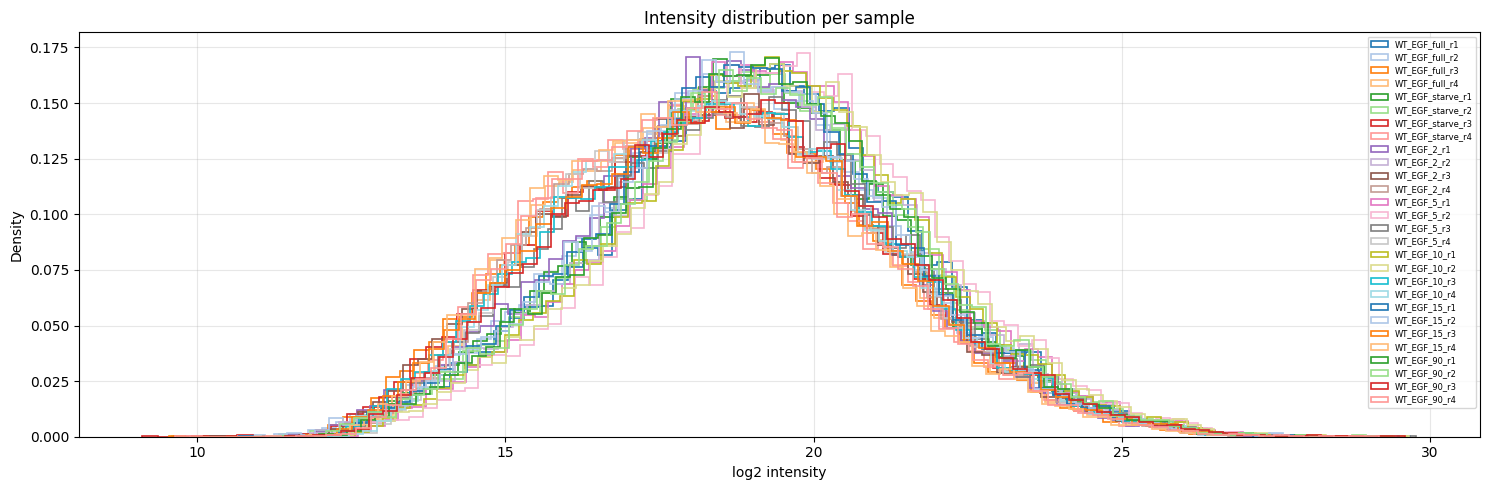

In [10]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
intensity_distribution(
    hme1_2,
    cell_lines=["WT"], #["WT"],  #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"],#, "_INS_","_EGFnINS_"],
    data_type="log2:abs",
    log_transform= False,
    figsize=(15,5),
    title="Intensity distribution per sample",
    ax=None,
)

## CV variance

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/QC.py:1348: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'CV distribution per timepoint'}, xlabel='Condition / timepoint', ylabel='CV (%)'>)

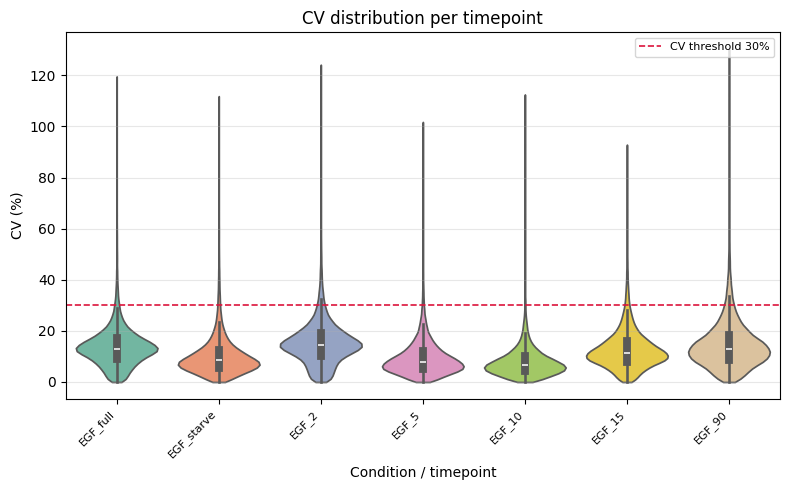

In [11]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
cv_distribution(
    hme1_2,
    cell_lines=["WT"], #"BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:cv",
    cv_threshold=30.0,
    figsize=None,
    title="CV distribution per timepoint",
    ax=None,
)

## PCA of conditions

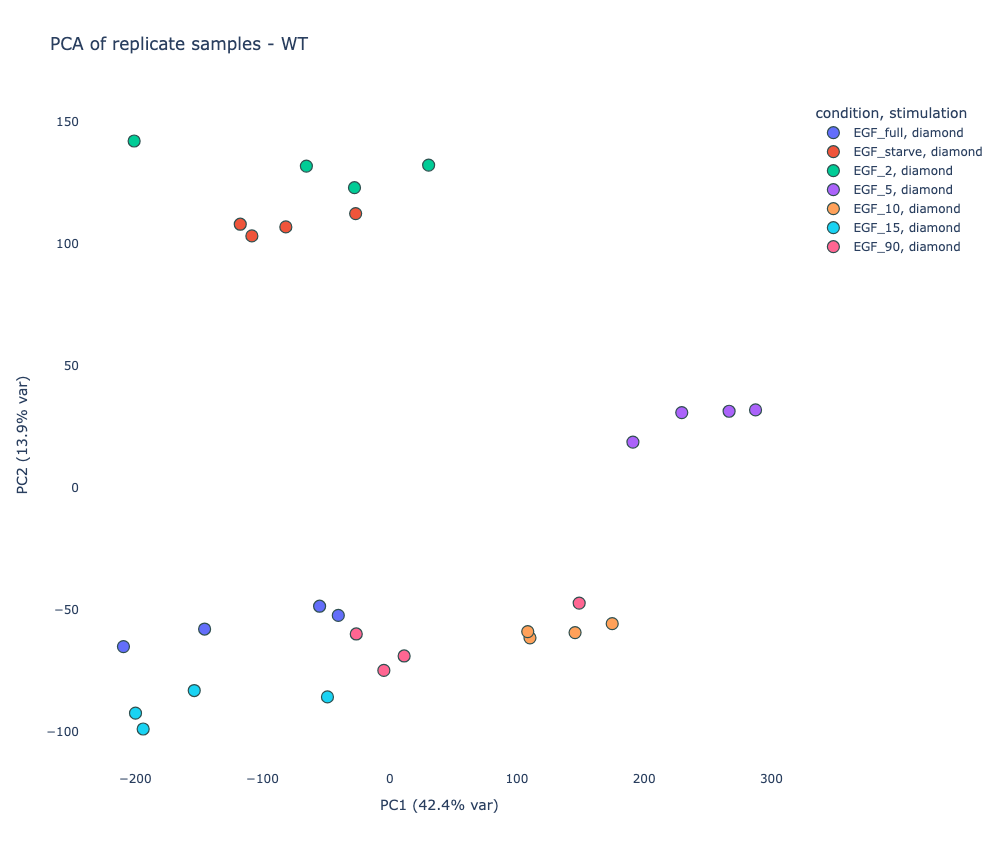

In [12]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
fig_scatter, fig_variance, pca_df = pca_plot_interactive(
                                                        hme1_2,
                                                        cell_lines= ["WT"], #, "BRAFS151A", "GAB1Y259A"],
                                                        conditions=["_EGF_"],# "_INS_","_EGFnINS_"],
                                                        data_type="log2:abs",
                                                        n_components=5,
                                                        impute=True,
                                                        impute_method="mean",
                                                        color_by="condition", #condition  cell_line
                                                        figsize=(1000, 850), #(1000, 800)
                                                        title="PCA of replicate samples - WT",
                                                    )
fig_scatter.show()

## PCA of condition centroids

One point per `(cell_line, condition, timepoint)` group instead of one per replicate, so the
biological trajectory is readable when the replicate-level plot above is too crowded.

**`centroid_space` decides where the averaging happens, and the two are different plots.**

| | `"pca"` (default) | `"data"` |
|---|---|---|
| what is averaged | the replicates' **PC coordinates** | the replicates' **intensities**, before the PCA |
| embedding | **identical** to the PCA above — axes and % variance are directly comparable | a **new** PCA on the group matrix; loadings, axes and % variance all change |
| replicate spread | survives, drawn as the error bars | gone — averaged away before the fit |
| sites kept | only sites complete in **every replicate** | sites complete in **every group** |

That last row is not a detail on this data: on hme1_2 the replicate-level PCA keeps
**2896 / 8723** sites, the group-level one keeps **8723 / 8723** — a site missing in one replicate
still has a group mean. So `"data"` is fitted on ~3× more sites, which is a real argument for it,
paid for by losing comparability with the plot above.

⚠️ **Averaging always makes separation look cleaner than it is.** A centroid plot cannot tell you
whether groups are separated *relative to replicate scatter* — that is exactly the information
averaging removes. Read the error bars before believing a separation: if they overlap, the groups
are not resolved no matter how far apart the centroids sit. When the question is replicate
agreement or outlier detection, use the replicate-level PCA above, not this one.


In [ ]:
# Centroid PCA — same embedding as the replicate PCA above (centroid_space="pca"),
# so the axes and the % variance can be compared directly between the two figures.
fig_scatter, fig_variance, centroid_df = pca_centroid_plot_interactive(
                                                        hme1_2,
                                                        cell_lines=["WT"],
                                                        conditions=["_EGF_"],# "_INS_","_EGFnINS_"],
                                                        data_type="log2:abs",
                                                        n_components=5,
                                                        impute=True,
                                                        impute_method="mean",
                                                        centroid_space="pca",   # "pca" | "data"
                                                        centroid_stat="mean",   # "mean" | "median"
                                                        color_by="condition",   # condition | cell_line
                                                        symbol_by="timepoint",
                                                        error_bars="sd",        # "sd" | "sem" | None
                                                        show_replicates=True,   # faint replicate cloud behind
                                                        figsize=(1000, 850),
                                                        title="PCA of condition centroids - WT",
                                                    )
fig_scatter.show()

# n_reps and the per-PC spread behind each centroid
centroid_df[["group", "condition", "timepoint", "n_reps", "PC1", "PC2", "PC1_sd", "PC2_sd"]]


## UMAP of conditions — read before interpreting

**For checking that replicates of a timepoint group together, use the PCA above, not the UMAP below.**

The `full` and `starve` timepoints are duplicated across the EGF / INS / EGFnINS conditions (they are the same physical samples, repeated only for convenient data handling). In **PCA** these duplicates overlap exactly — PCA is a deterministic linear projection, so identical feature vectors map to the same coordinate. In **UMAP** they appear **separated**: UMAP is a stochastic, graph-based force-directed layout where every sample is a separate node, and its repulsion term pushes even identical points apart regardless of `random_state`. That separation is an algorithm artifact, **not** a data or imputation problem.

So: use **PCA** for replicate-agreement and outlier QC. Treat this sample-level UMAP as exploratory only. UMAP's real value is at the **site level** (see the site-level UMAP further down), where its non-linear neighborhood-preservation helps reveal phosphosite response groups. See `QC_notes.md` for the full PCA vs UMAP comparison.


/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


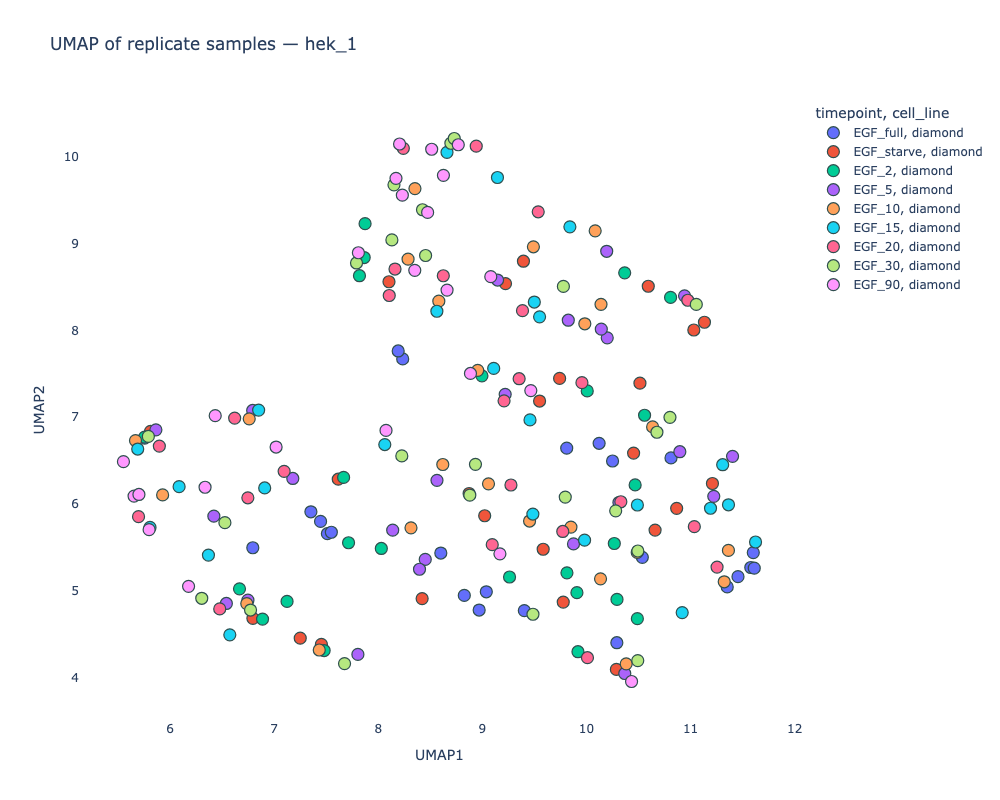

In [92]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
fig, umap = umap_plot_interactive(hme1_2,
                                  cell_lines=CELL_LINES, #["GAB1Y259A"], # "BRAFS151A", "GAB1Y259A"],
                                  conditions=["_EGF_"], #"_INS_","_EGFnINS_"],
                                  data_type="log2:abs",
                                  impute=True,
                                  impute_method="mean",
                                  n_neighbors=15,
                                  min_dist=0.1,
                                  random_state=42,
                                  color_by="timepoint", # "timepoint"  "cell_line"
                                  symbol_by="cell_line", # "cell_line"
                                  figsize=(1000, 800),
                                  title="UMAP of replicate samples — hek_1",)

fig.show()

## Distance between conditions (PCA centroids)

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


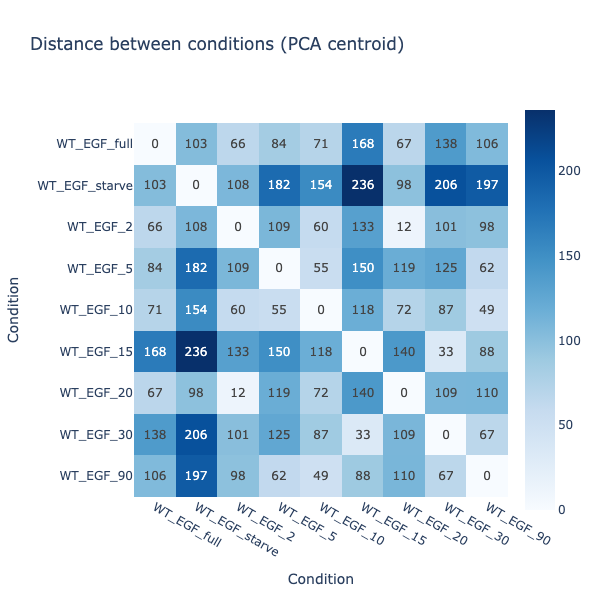

In [100]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
fig, dist_df, pca_df = pca_distance_heatmap(
                                            hme1_2,
                                            cell_lines=["WT"],
                                            conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                            data_type="log2:abs",
                                            impute=True,
                                            impute_method="mean",
                                            n_pca_components=3,
                                            centroid_stat="median",
                                            zmax=None,
                                            figsize=(600, 600),
                                            title="Distance between conditions (PCA centroid)",
                                        )
fig.show()

## UMAP of all samples
Not using individual replicates values

In [99]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
fig, ax = plot_sites_umap_interactive(hme1_2,
                                    cell_lines=["EGFRT693A"],
                                    conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                    data_type="log2:mean",
                                    exclude_full=True,
                                    color_col="protein_name", # None  "protein_name"
                                    hover_cols=None,
                                    n_neighbors=15,
                                    min_dist=0.1,
                                    random_state=42,
                                    figsize=(1000, 800),
                                    title=None,
)


fig.show()

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x102eb1fc0>
Traceback (most recent call last):
  File "/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/_weakrefset.py", line 39, in _remove
KeyboardInterrupt: 


SystemError: CPUDispatcher(<function nn_descent at 0x3980528c0>) returned a result with an exception set

# Differential statistics — limma

The p-values are **not** computed in Python. `notebooks/01_preprocessing/limma_for_pvalues.rmd`
fits a blocked linear model on `log2:abs` in R (each timepoint against the starve control **of its
own TMT plex**) and the results are merged onto the processed tables during preprocessing, as:

| Column | Meaning |
|---|---|
| `WT_log2:limmaFC_EGF_5` | moderated log2 fold change vs starve |
| `WT_log2:FDR_EGF_5` | BH-FDR of the moderated *t*-test at that timepoint |
| `WT_log2:FFDR_EGF_omnibus` | BH-FDR of the omnibus *F*-test: does the site differ from starve at **any** timepoint of that condition |

Two things are worth reading off these columns as QC, before any clustering:
**when** the responses happen, and **how much** of the dataset responds at all.

Sites limma could not test (detected in too few plexes) carry `NaN` and are never counted as
responsive — both functions report the tested count separately, so percentages can be read
against the right denominator.

## `"omnibus"` vs `"any_timepoint"` — what "responsive" means

Both functions below take this argument (`responsive=` in the peak plot, `method=` in the
responsiveness plot). Both definitions answer *"does this site respond to this stimulation?"*, and
they differ only in **how the timepoints are combined into one call**. Neither set contains the
other — each finds sites the other misses.

### `"omnibus"` — one moderated *F*-test per site per condition
Column: `WT_log2:FFDR_EGF_omnibus`

limma fits one linear model per site (`log2:abs ~ group + plex`), forms the five contrasts
`EGF_2 − starve`, …, `EGF_90 − starve`, and tests them **jointly**:

> H₀: all five coefficients are zero — the whole EGF time course is flat.

- **One p-value per site**, so BH runs over sites only (~n_sites tests). The 5% FDR means what it
  says.
- **Pools evidence across timepoints.** A site with a consistent moderate change at 5, 10 and 15
  min can pass the *F* while failing every individual *t*-test — sustained responses gain power.
- **Cost: transients are diluted.** The *F* spreads the signal over all five contrasts, so a
  single sharp spike at 2 min against four flat points is *less* likely to pass than its own
  *t*-test at 2 min. The omnibus is the conservative choice for short-lived responses.
- Says only **that** a site moved, never **when** — the peak-timepoint plot supplies the "when".
- **`full` is already excluded upstream.** `limma_for_pvalues.rmd` builds the *F* over
  `setdiff(timepoints, c("full", "starve"))`, so `exclude_full` has no effect on this option
  (it still applies to `min_fc`, which is computed from the FC columns here).

### `"any_timepoint"` — the OR of the per-timepoint moderated *t*-tests
Columns: `WT_log2:FDR_EGF_2`, `WT_log2:FDR_EGF_5`, …

Each contrast is BH-corrected **across sites, separately per contrast** (`p.adjust(p, "BH")` per
column in the R code); a site is then called responsive if *at least one* timepoint passes.

- **Multiplicity across timepoints is not controlled.** Each column holds 5% FDR internally, their
  union does not. For *m* timepoints the union's false-positive rate sits between 5% and
  ~1 − (1 − 0.05)ᵐ (23% at m = 5); the truth is nearer the low end because consecutive timepoints
  are strongly correlated, but it is not 5%.
- **The count therefore grows with the size of the timepoint grid.** hme1_2 has 5 stimulation
  points, hme1_lfq will have 7 — "% responsive" computed this way is *not comparable* between
  datasets. The omnibus is one test either way, so it is.
- **Gain: sensitive to a single sharp spike**, and it tells you which timepoint drove the call.
- **`exclude_full=True` matters here.** `WT_log2:FDR_EGF_full` exists, and full media vs starve is
  a difference in culture condition, not a response to stimulation — leaving it in would label
  quiescence-related sites "EGF responsive".

### Which to use
Use **`"omnibus"`** for filtering and for any number you report; it is what `MAX_FFDR` in
`03_clustering/Clustering.ipynb` already filters on, so the QC here and the clustering input stay
consistent. Use **`"any_timepoint"`** as a diagnostic: if it returns many more sites, inspect
whether those extras are genuine single-timepoint transients (which the *F* under-detects) or
scattered noise (the multiplicity leak). Running both and comparing the two counts is the point of
having the switch.

Related column, not used by these functions: `WT_log2:FFDR_ALL_omnibus` is the *F* over all 15
stimulation contrasts of all three conditions at once — "does this site respond to anything",
as a single test instead of an OR over three per-condition omnibus tests.

## Timing of the response — when do sites peak?

For every responsive site, the peak is the timepoint with the largest **|limma log2 FC|**, so a
strong dephosphorylation counts as a peak exactly like a strong phosphorylation — the question is
*where the response is strongest*, not in which direction it goes. Set `split_direction=True` to
split each bar into up- and down-regulated peaks.

Only sites limma calls responsive in that condition are counted (`responsive=None` would count
every tested site): a non-responding site still has a largest-|FC| timepoint, driven purely by
noise, and including those adds a flat background that hides the real timing distribution.

- `conditions` — pass one token (`"EGF"`) or several (`["EGF", "INS", "EGFnINS"]`, grouped bars)
- `exclude_full=True` — `full` is a separate culture condition, not a point on the time course
- `min_fc` — optional effect-size floor on top of significance

Timepoint of peak |limma fold change| — sites responsive by omnibus FDR < 0.05 and |log2FC| >= 0.5:
  EGF: 7585 sites counted
  INS: 2950 sites counted
  EGFnINS: 8588 sites counted
            EGF  INS  EGFnINS  EGF_pct  EGF_up  EGF_down  INS_pct  INS_up  INS_down  EGFnINS_pct  EGFnINS_up  EGFnINS_down
timepoint                                                                                                                 
2           288  471      380      3.8     169       119     16.0     451        20          4.4         336            44
5          3158  603      926     41.6    3144        14     20.4     579        24         10.8         883            43
10         2525  991     4588     33.3    2380       145     33.6     963        28         53.4        4444           144
15          989  210     1332     13.0      75       914      7.1      55       155         15.5        1067           265
90          625  675     1362      8.2     576        49     22.9     643       

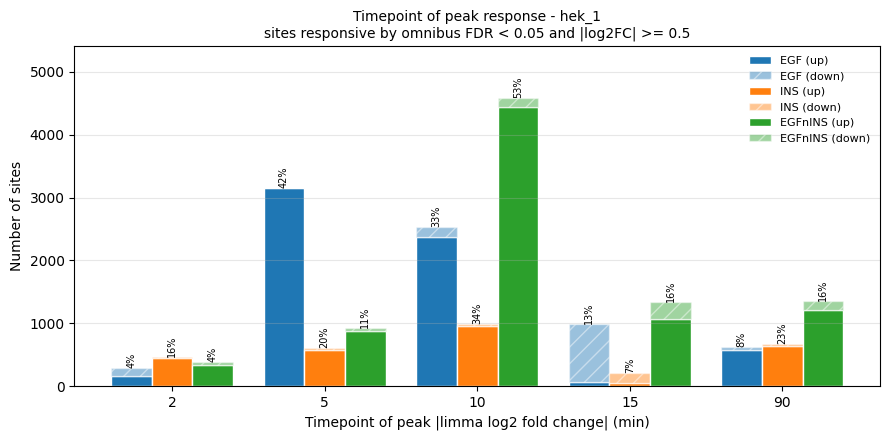

In [13]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
peak_table, fig, ax = limma_peak_timepoints(
    hme1_2,
    cell_line="WT",
    conditions=["EGF", "INS", "EGFnINS"],   # or a single condition: "EGF"
    fdr_threshold=0.05,
    responsive="omnibus",                   # "omnibus" | "any_timepoint" | None
    min_fc=0.5,                            # e.g. 0.5 to also require an amplitude
    exclude_full=True,
    split_direction=True,                  # True = split each bar into up / down peaks
    title="Timepoint of peak response - hek_1",
)

## How much of the dataset responds?

Left panel: responsive sites per condition, plus an `any condition` bar. Right panel: in how many
conditions each site responds — the `0` bar is the unresponsive remainder, everything to its right
is the responsive fraction split by how specific the response is.

`method="omnibus"` (recommended) vs `method="any_timepoint"`: see the explanation at the top of
this section. Rerunning this cell with the other setting is the quickest way to see how much of
the responsive set depends on the definition rather than on the biology.

Percentages in the plot are of **all** sites in the table; the printed summary also gives them as
a percentage of the sites limma actually tested, which is the fairer denominator.

Responsive sites (omnibus FDR < 0.05, |log2FC| >= 0.5) — 50002 sites in the dataset, 33719 tested by limma:
               n_tested  n_responsive  pct_of_all  pct_of_tested
condition                                                       
EGF               33719          7585        15.2           22.5
INS               33719          2950         5.9            8.7
EGFnINS           33719          8588        17.2           25.5
any condition     33719         10411        20.8           30.9

In how many conditions is a site responsive:
                         n_sites  pct_of_all
n_conditions_responsive                     
0                          39591        79.2
1                           4045         8.1
2                           4020         8.0
3                           2346         4.7


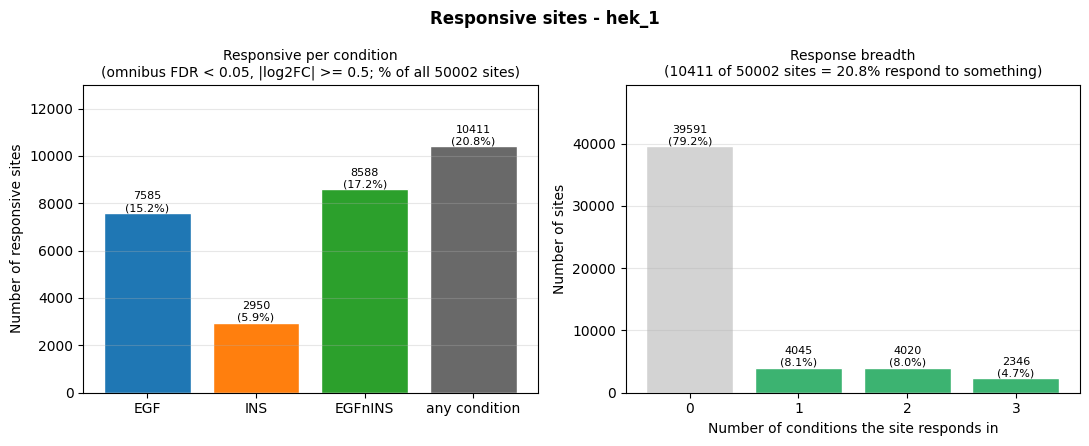

In [14]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
responsive_table, specificity_table, fig, axes = limma_responsive_sites(
    hme1_2,
    cell_line="WT",
    conditions=["EGF", "INS", "EGFnINS"],
    fdr_threshold=0.05,
    method="omnibus",                       # "omnibus" | "any_timepoint"
    min_fc=0.5,                            # e.g. 0.5 to also require an amplitude
    exclude_full=True,
    title="Responsive sites - hek_1",
)

# Datasets comparison

Compare phosphosite identity across the four raw MSMS datasets:
- `hek_1` — HEK293T experiment 1
- `hme1_1` — hTERT-HME1 experiment 1
- `hme1_2` — hTERT-HME1 experiment 2
- `hme1_mutants` — hTERT-HME1 mutant cell lines

Analyses:
- Venn diagrams of shared phosphosites
- Pairwise overlap summary table (n detected, n shared, % overlap)
- WT vs mutant overlap (critical for classifier transfer)

## Venn diagrams

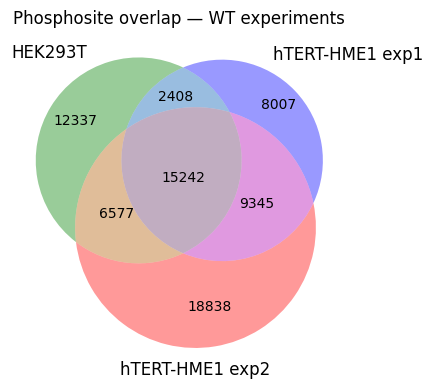

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Phosphosite overlap — WT experiments'}>)

In [21]:
# ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"]
# hTERT-HME1 replicate experiments + HEK293T
venn_diagrams(
    data_frames=[hek_1, hme1_1, hme1_2],
    labels=["HEK293T", "hTERT-HME1 exp1", "hTERT-HME1 exp2"],
    colors=["green", "blue", "red"],
    title="Phosphosite overlap — WT experiments",
    column_to_compare="site",
)

In [ ]:
# hTERT-HME1 WT (exp1) vs mutant dataset
# Critical for classifier transfer: only shared sites can be used to propagate cluster labels
venn_diagrams(
    data_frames=[hme1_1, hme1_mutants],
    labels=["hTERT-HME1 WT", "hTERT-HME1 mutants"],
    colors=["blue", "orange"],
    title="Phosphosite overlap — WT vs mutant (hTERT-HME1)",
    column_to_compare="site",
)

## Pairwise overlap summary

Quantitative table of n detected, n shared, and % overlap for every dataset pair.
`pct_A_in_B` = % of dataset A's sites also found in B (coverage from A's perspective).

In [ ]:
overlap_summary(
    data_frames=[hek_1, hme1_1, hme1_2],
    labels=["HEK293T", "hTERT-HME1 exp1", "hTERT-HME1 exp2"],
    column_to_compare="site",
)